## load packages

In [1]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder 
from sklearn.preprocessing import RobustScaler, StandardScaler, PolynomialFeatures, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
import optuna

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

import keras
from scikeras.wrappers import KerasClassifier

#from sklearn.tree import DecisionTreeClassifier
#from sklearn.neighbors import KNeighborsClassifier
#from sklearn.neural_network import MLPClassifier
#from sklearn.linear_model import LogisticRegression
#from sklearn.svm import SVC

## Load data

In [2]:
df_train = pd.read_csv('data/train.csv', index_col='id')
df_test = pd.read_csv('data/test.csv', index_col='id')

In [3]:
df_train.shape, df_test.shape

((11504798, 11), (7669866, 10))

~11.5million datapoints in training set, ~7.5million datapoints in test set 

In [5]:
# outside of target column ('Response'), train and test share same columns in same order
list(df_train.columns)[:-1] == list(df_test.columns)

True

In [4]:
# change column names to be all lowercase
df_train.rename(columns=lambda col : col.lower(), inplace=True)
df_test.rename(columns=lambda col : col.lower(), inplace=True)

In [5]:
df_train.head(10)

,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
id,,,,,,,,,,,
0,Male,21,1,35.0,0,1-2 Year,Yes,65101.0,124.0,187,0
1,Male,43,1,28.0,0,> 2 Years,Yes,58911.0,26.0,288,1
2,Female,25,1,14.0,1,< 1 Year,No,38043.0,152.0,254,0
3,Female,35,1,1.0,0,1-2 Year,Yes,2630.0,156.0,76,0
4,Female,36,1,15.0,1,1-2 Year,No,31951.0,152.0,294,0
5,Female,31,1,47.0,1,< 1 Year,No,28150.0,152.0,197,0
6,Male,23,1,45.0,1,< 1 Year,No,27128.0,152.0,190,0
7,Female,47,1,8.0,0,1-2 Year,Yes,40659.0,26.0,262,1
8,Female,26,1,28.0,1,< 1 Year,No,31639.0,152.0,36,0


## Visualize data distribution

In [5]:
# we see that for the target, there are far more y=0 rows than there are y=1 rows
    # as we might expect in real-life scenarios, most customers were NOT interested in buying new insurance
df_train.response.value_counts()

response
0    10089739
1     1415059
Name: count, dtype: int64

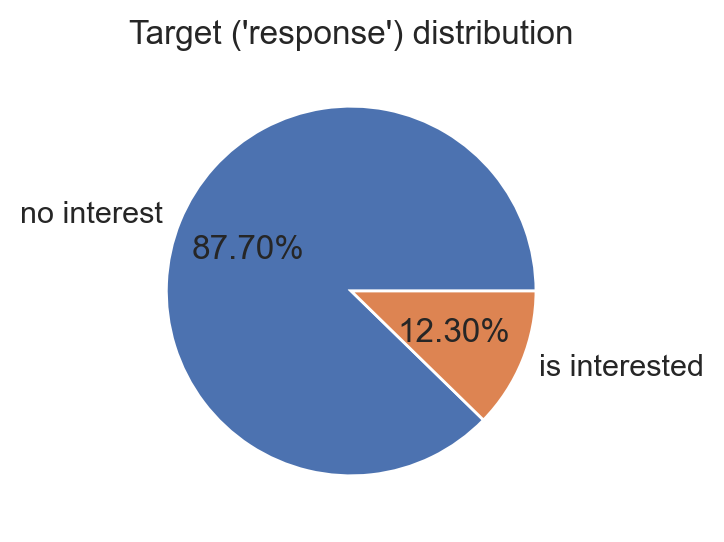

In [7]:
# visual representation of target values

y_train_counts = df_train.response.value_counts()

plt.figure(figsize=(6, 3))
plt.pie(y_train_counts, labels=["no interest", "is interested"], autopct="%.2f%%") # show percentages (down to 2d.p. & include  pct symbol)
plt.title("Target ('response') distribution")
plt.show()

In [8]:
# bar plots for categorical features with few unique values
# histograms for continuous features and categorical features with many unique values

all_cols = list(df_train.columns)
num_cols = ['age', 'annual_premium', 'vintage']
large_cat_cols = ['region_code', 'policy_sales_channel']
cat_cols = [col for col in all_cols if (col not in num_cols) & (col not in large_cat_cols)] 

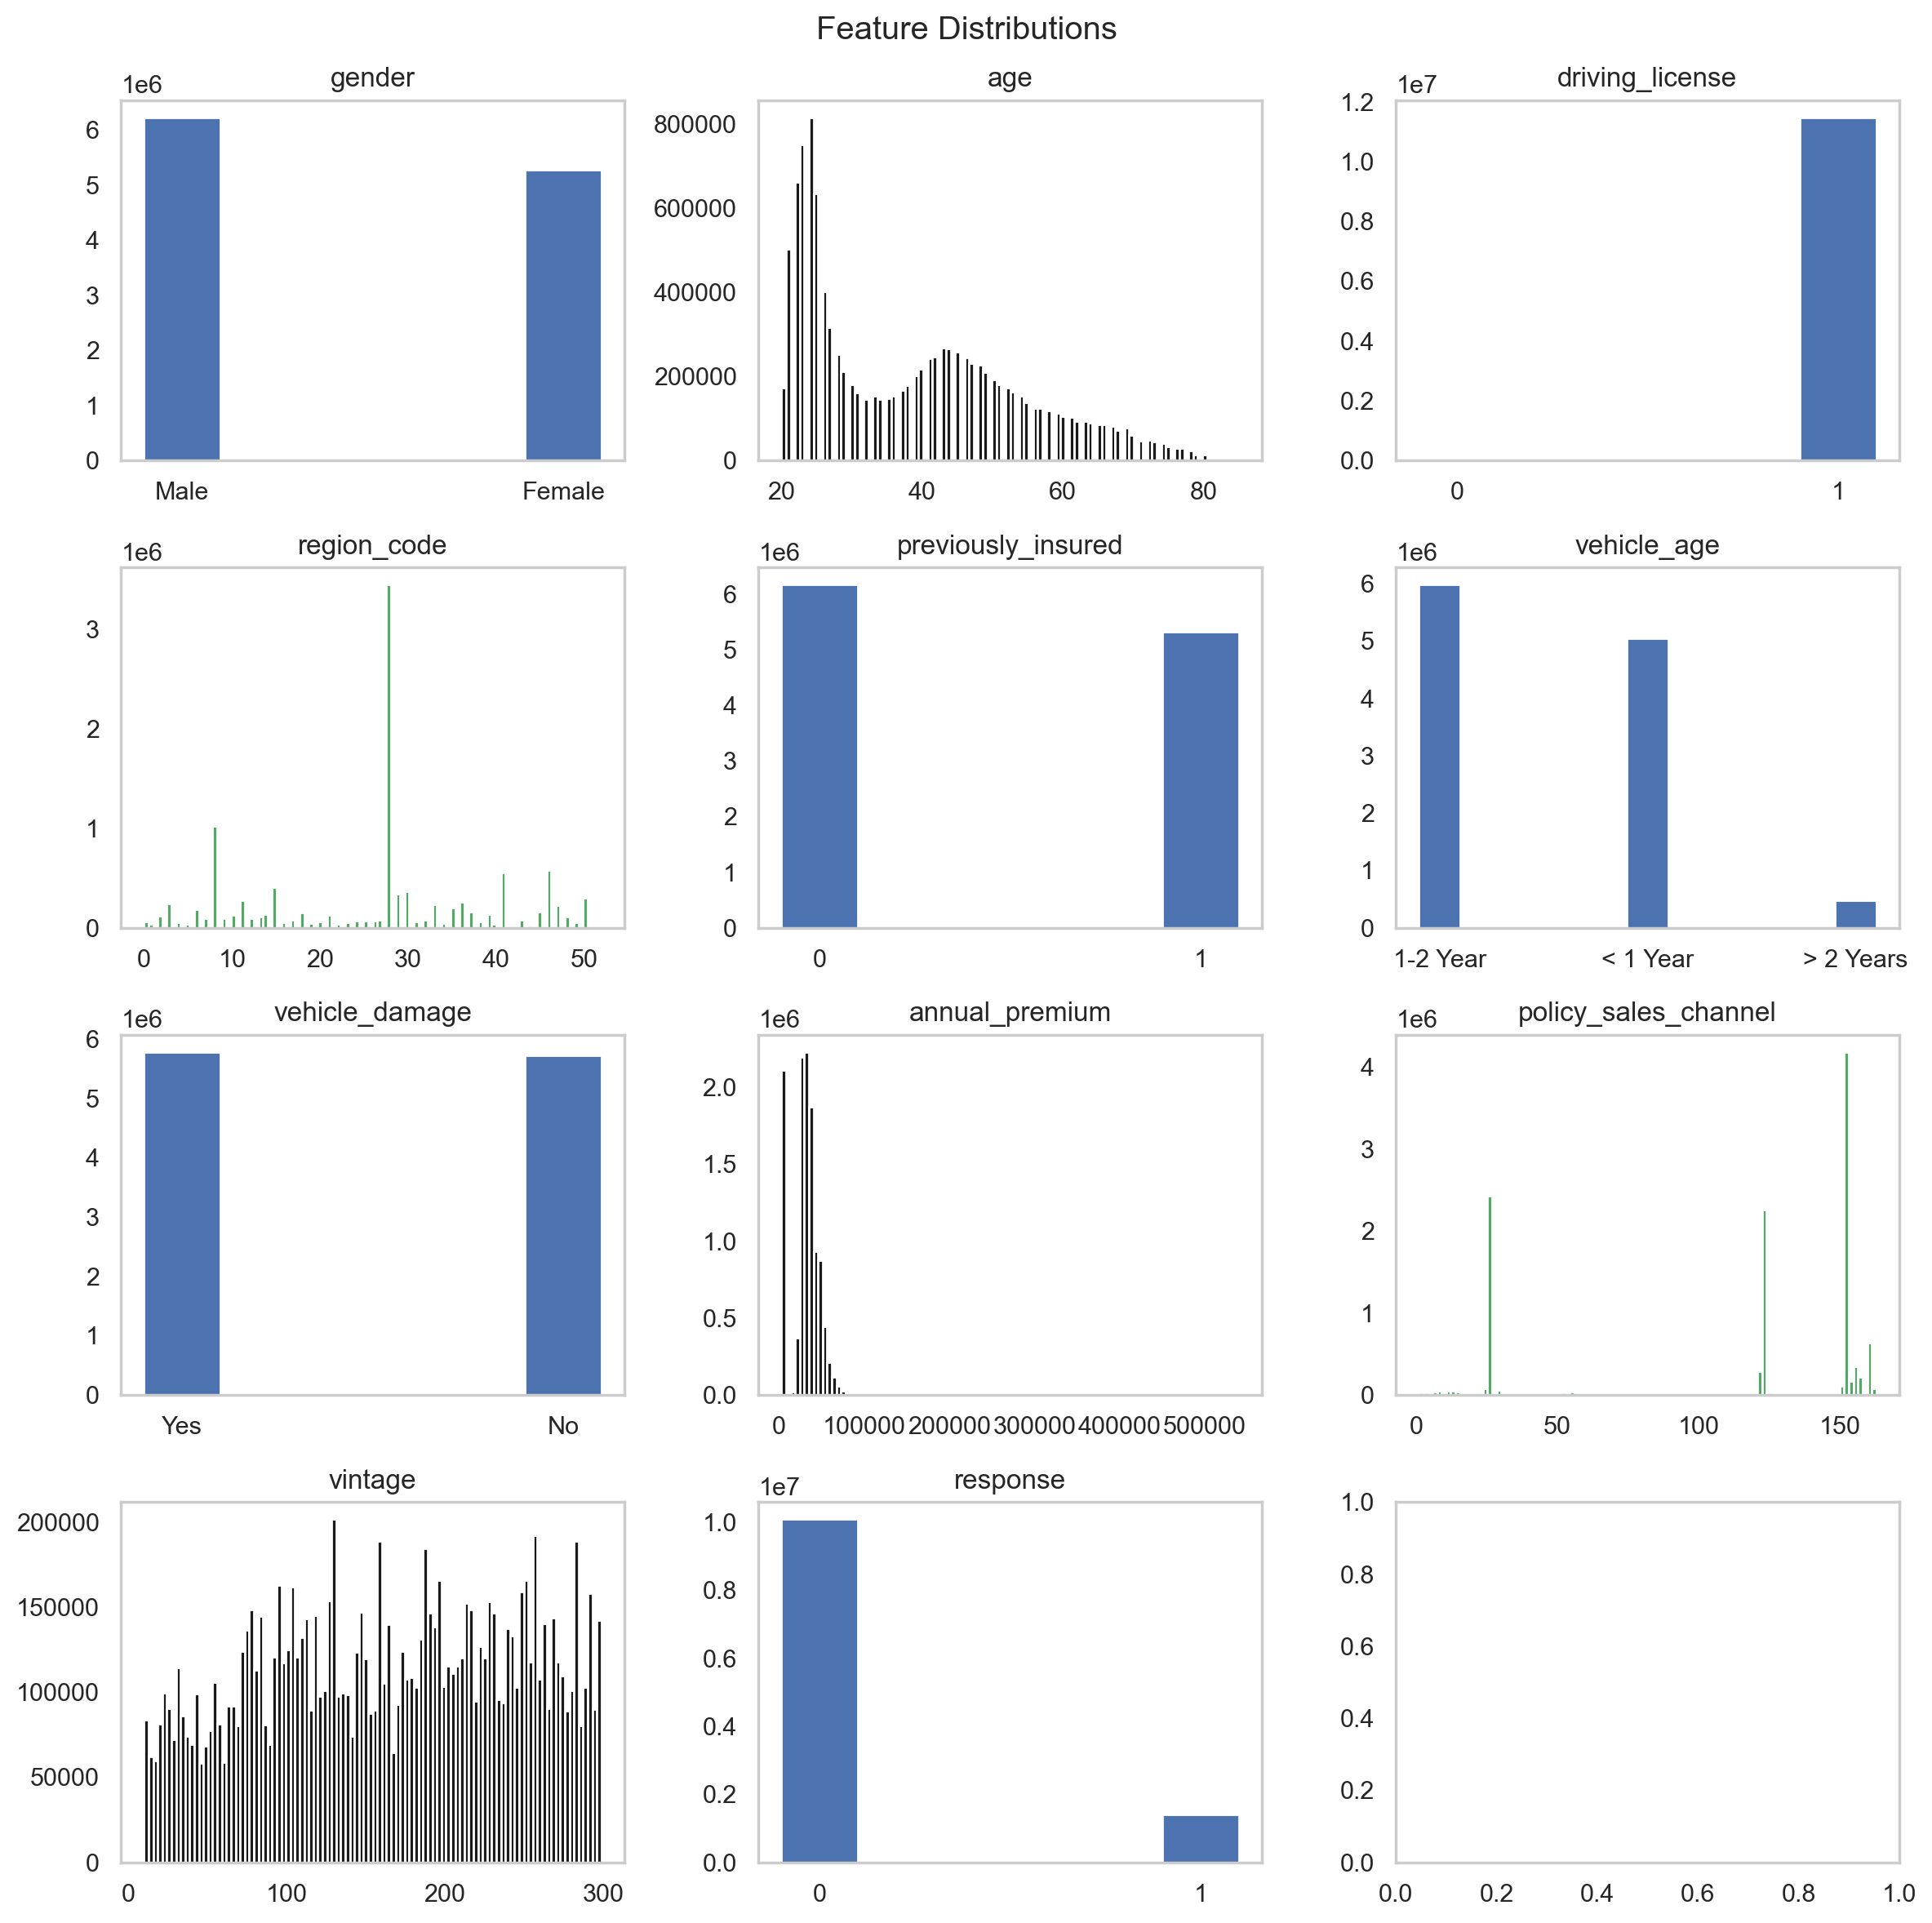

In [9]:
fig, axs = plt.subplots(4,3, figsize=(12, 12))

for i, ax in enumerate(axs.ravel()):
    if i <= 10:
        col = all_cols[i]
        if col in num_cols:
            ax.hist(df_train[col], bins=100, color='k')
        elif col in large_cat_cols:
            ax.hist(df_train[col], bins=100, color='g')
        else:
            x_vals = df_train[col].value_counts().index
            ax.bar(x=x_vals, height=df_train[col].value_counts().values, width=0.2, color='b')
            ax.set_xticks(x_vals, x_vals)
        ax.set_title(col)
        ax.grid(False)

plt.suptitle("Feature Distributions")        
plt.tight_layout()
plt.grid(False)
plt.show()

## Handle missing values

In [12]:
df_train.isna().sum()

gender                  0
age                     0
driving_license         0
region_code             0
previously_insured      0
vehicle_age             0
vehicle_damage          0
annual_premium          0
policy_sales_channel    0
vintage                 0
response                0
dtype: int64

In [13]:
df_train.isnull().sum()

gender                  0
age                     0
driving_license         0
region_code             0
previously_insured      0
vehicle_age             0
vehicle_damage          0
annual_premium          0
policy_sales_channel    0
vintage                 0
response                0
dtype: int64

no missing values to impute in our dataset!

## Data preprocessing

In [10]:
df_train.dtypes

gender                   object
age                       int64
driving_license           int64
region_code             float64
previously_insured        int64
vehicle_age              object
vehicle_damage           object
annual_premium          float64
policy_sales_channel    float64
vintage                   int64
response                  int64
dtype: object

- first, we can lay out the appropriate dtypes for every feature in our data
- information taken from https://github.com/ankit986/HEALTH-INSURANCE-CROSS-SELL-PREDICTION
    
#### feature column "types"
- binary & unordered categorical
    - gender: binary categorical ('Male', 'Female')
    - driving_license: binary categorical (0, 1 representing "no license", "has license")
    - previously_insured: binary categorical (0, 1 representing "no insurance", "has insurance")
    - vehicle_damage: binary categorical (0,1 representing "no previous damage", "had previous damage")
    - region_code: categorical int (each region is denoted by a unique integer)
    - policy_sales_channel: categorical int
- ordered categorical
    - vehicle_age: ordinal categorical (each value in this column falls into one of several bins that can be ordered by 'age duration')
- continous
    - age: continuous int
    - annual_premium: continuous int
    - vintage: continuous int (number of days customer has been with the company)

#### how to handle them
- binary features -> OrdinalEncoder
- unordered categorical features -> OrdinalEncoder (default settings)
- ordered categorical features -> OrdinalEncoder with 'categories' parameter set to reflect correct hierarchy
- continuous features -> RobustScaler

In [15]:
for cat_col in ['region_code','vehicle_age','policy_sales_channel']:
    vals = df_train[cat_col].unique()
    count = len(df_train[cat_col].unique())
    
    print(f"'{cat_col}' has {count} unique values, which are: \n {vals} \n")

'region_code' has 54 unique values, which are: 
 [35.  28.  14.   1.  15.  47.  45.   8.  11.   3.  10.  12.  37.  50.
 30.  46.  29.  16.  26.  25.  41.  48.   7.   4.  24.  36.  33.   2.
  9.  27.  18.  43.  49.  17.  13.  38.   6.  21.  23.   0.  19.   5.
 39.  44.  20.  40.  22.  32.  42.  31.  34.  51.  52.  39.2] 

'vehicle_age' has 3 unique values, which are: 
 ['1-2 Year' '> 2 Years' '< 1 Year'] 

'policy_sales_channel' has 152 unique values, which are: 
 [124.  26. 152. 156. 160.   8.  31. 157.  60. 122.  15.  30. 147.   1.
  63. 136. 154.  18. 135. 151.   3.  10.  55. 108.   7.  29. 163.  13.
 133. 145.  25.  12. 109.  23.  78.   4. 153. 150. 146. 120. 107. 155.
  61.  14.  45.  11.  19.  24.  52. 132. 125.  59.  16.  22.  56.  20.
 148. 158. 159. 139.   9. 113. 121.  21. 111.  64. 116. 103. 128.  65.
  37.  91. 129. 127. 106. 140.  35. 131.  17.  93.  90.  36. 118.  54.
  62. 138.  42.  46.  86.  80.  68. 119.  94.  48.  47.  83.  97.  70.
  53.  44. 114.  98.  88. 110.  32.

In [16]:
sum(df_train['region_code'] == 39.2)
# only 1 row in training data has a non-integer value

1

- we can summize as follows:
    - region_code and policy_sales_channel are unordered categorical features, but since they each have many distinct values they are unsuited to one-hot encoding
    - region_code has single row with a non-integer value -> drop this row
        - once that row is dropped, we can apply ordinal encoding to both of these features
    - vehicle_age has ordinal values
        - use ordinal encoding but with the categories' order clearly defined 

In [6]:
drop_idx = df_train.loc[df_train['region_code'] == 39.2].index[0]
df_train.drop(index=drop_idx, inplace=True)
df_train.reset_index(drop=True, inplace=True)

In [7]:
df_train.shape

(11504797, 11)

In [12]:
X_train = df_train.copy()
X_train = X_train.drop(columns=["response"])
y_train = df_train['response']

X_test = df_test.copy()

In [13]:
X_train[['region_code', 'policy_sales_channel']] = X_train[['region_code', 'policy_sales_channel']].astype('int64')
X_test[['region_code', 'policy_sales_channel']] = X_test[['region_code', 'policy_sales_channel']].astype('int64')

In [14]:
feature_cols = list(X_train.columns)
num_cols = ['age', 'annual_premium', 'vintage']
cat_cols = [col for col in feature_cols if (col not in num_cols) & (col!="vehicle_age")] 

- initialize a ColumnTransformer instance, and use it to apply relevant transformations to each column in both training and test data
    - all cat columns are ordinal encoded without user-defined category list (because the categories have no hierarchical order)
           - only exception is 'vehicle_age', for which we specify category order (so that newer cars are encoded with smaller number than older cars) 
    - continuous/numerical columns are standardized using RobustScaler

In [15]:
# num_cols has all continuous columns' names
# cat_cols has all categorical columns' names (EXCEPT 'vehicle_age')

col_transform = ColumnTransformer([
    ('cat_encoder', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
    ('ordinal_encoder', OrdinalEncoder(categories=[['< 1 Year', '1-2 Year', '> 2 Years']]), ['vehicle_age']),
    ('num_scaler', RobustScaler(), num_cols)], 
    remainder="passthrough")
col_transform.set_output(transform='pandas')

X_train = col_transform.fit_transform(X_train)
X_test = col_transform.transform(X_test)

In [16]:
# restore the column names
new_col_names = [name.split("__")[1] for name in X_train.columns]
X_train.columns = new_col_names
X_test.columns = new_col_names

In [17]:
X_train.head(10)

,gender,driving_license,region_code,previously_insured,vehicle_damage,policy_sales_channel,vehicle_age,age,annual_premium,vintage
0,1.0,1.0,35.0,0.0,1.0,119.0,1.0,-0.60,2.347749,0.157895
1,1.0,1.0,28.0,0.0,1.0,25.0,2.0,0.28,1.911034,0.917293
2,0.0,1.0,14.0,1.0,0.0,142.0,0.0,-0.44,0.438761,0.661654
3,0.0,1.0,1.0,0.0,1.0,146.0,1.0,-0.04,-2.059687,-0.676692
4,0.0,1.0,15.0,1.0,0.0,142.0,1.0,0.00,0.008960,0.962406
5,0.0,1.0,47.0,1.0,0.0,142.0,0.0,-0.20,-0.259207,0.233083
6,1.0,1.0,45.0,1.0,0.0,142.0,0.0,-0.52,-0.331311,0.180451
7,0.0,1.0,8.0,0.0,1.0,25.0,1.0,0.44,0.623324,0.721805
8,0.0,1.0,28.0,1.0,0.0,142.0,0.0,-0.40,-0.013052,-0.977444
9,0.0,1.0,11.0,0.0,1.0,25.0,1.0,1.20,-2.059687,-0.308271


In [18]:
# ensure cat cols' dtypes are all 'category'

cat_cols = new_col_names[:-3]
X_train[cat_cols] = X_train[cat_cols].astype('category')
X_test[cat_cols] = X_test[cat_cols].astype('category')

## EDA

- let's consider both correlation (Pearson correlation coefficient) and mutual information for our features
- CORRELATION: 
    - is concerned with the LINEAR distance between 2 random variables i.e. only cares about strength of linear relationship between two features. It won't pick up on non-linear relationships regardless of how strong or weak that relationship may be.
    - with Pearson's correlation, the resulting value is standardized to fall within [-1,1] range where 0 means no correlation, and the more extreme the value (either positive or negative), the more strong the correlation 
    - simply put: high correlation signifies a simple "when feature_1 goes up, so does feature_2"
- MUTUAL INFORMATION
    - MI measures "the reduction of uncertainty in Y after observing X"
    - this means X and Y may not show strong linear correlation, but if there is some clear pattern/relationship between them (and this relationship does NOT have to be linear), then knowing X informs us about what to expect for Y, and thus we say there is high mutual information between X and Y
    - MI is unstandardized so its range is [0, inf]. MI is zero if and only if the 2 variables are independent, while higher values mean higher dependency


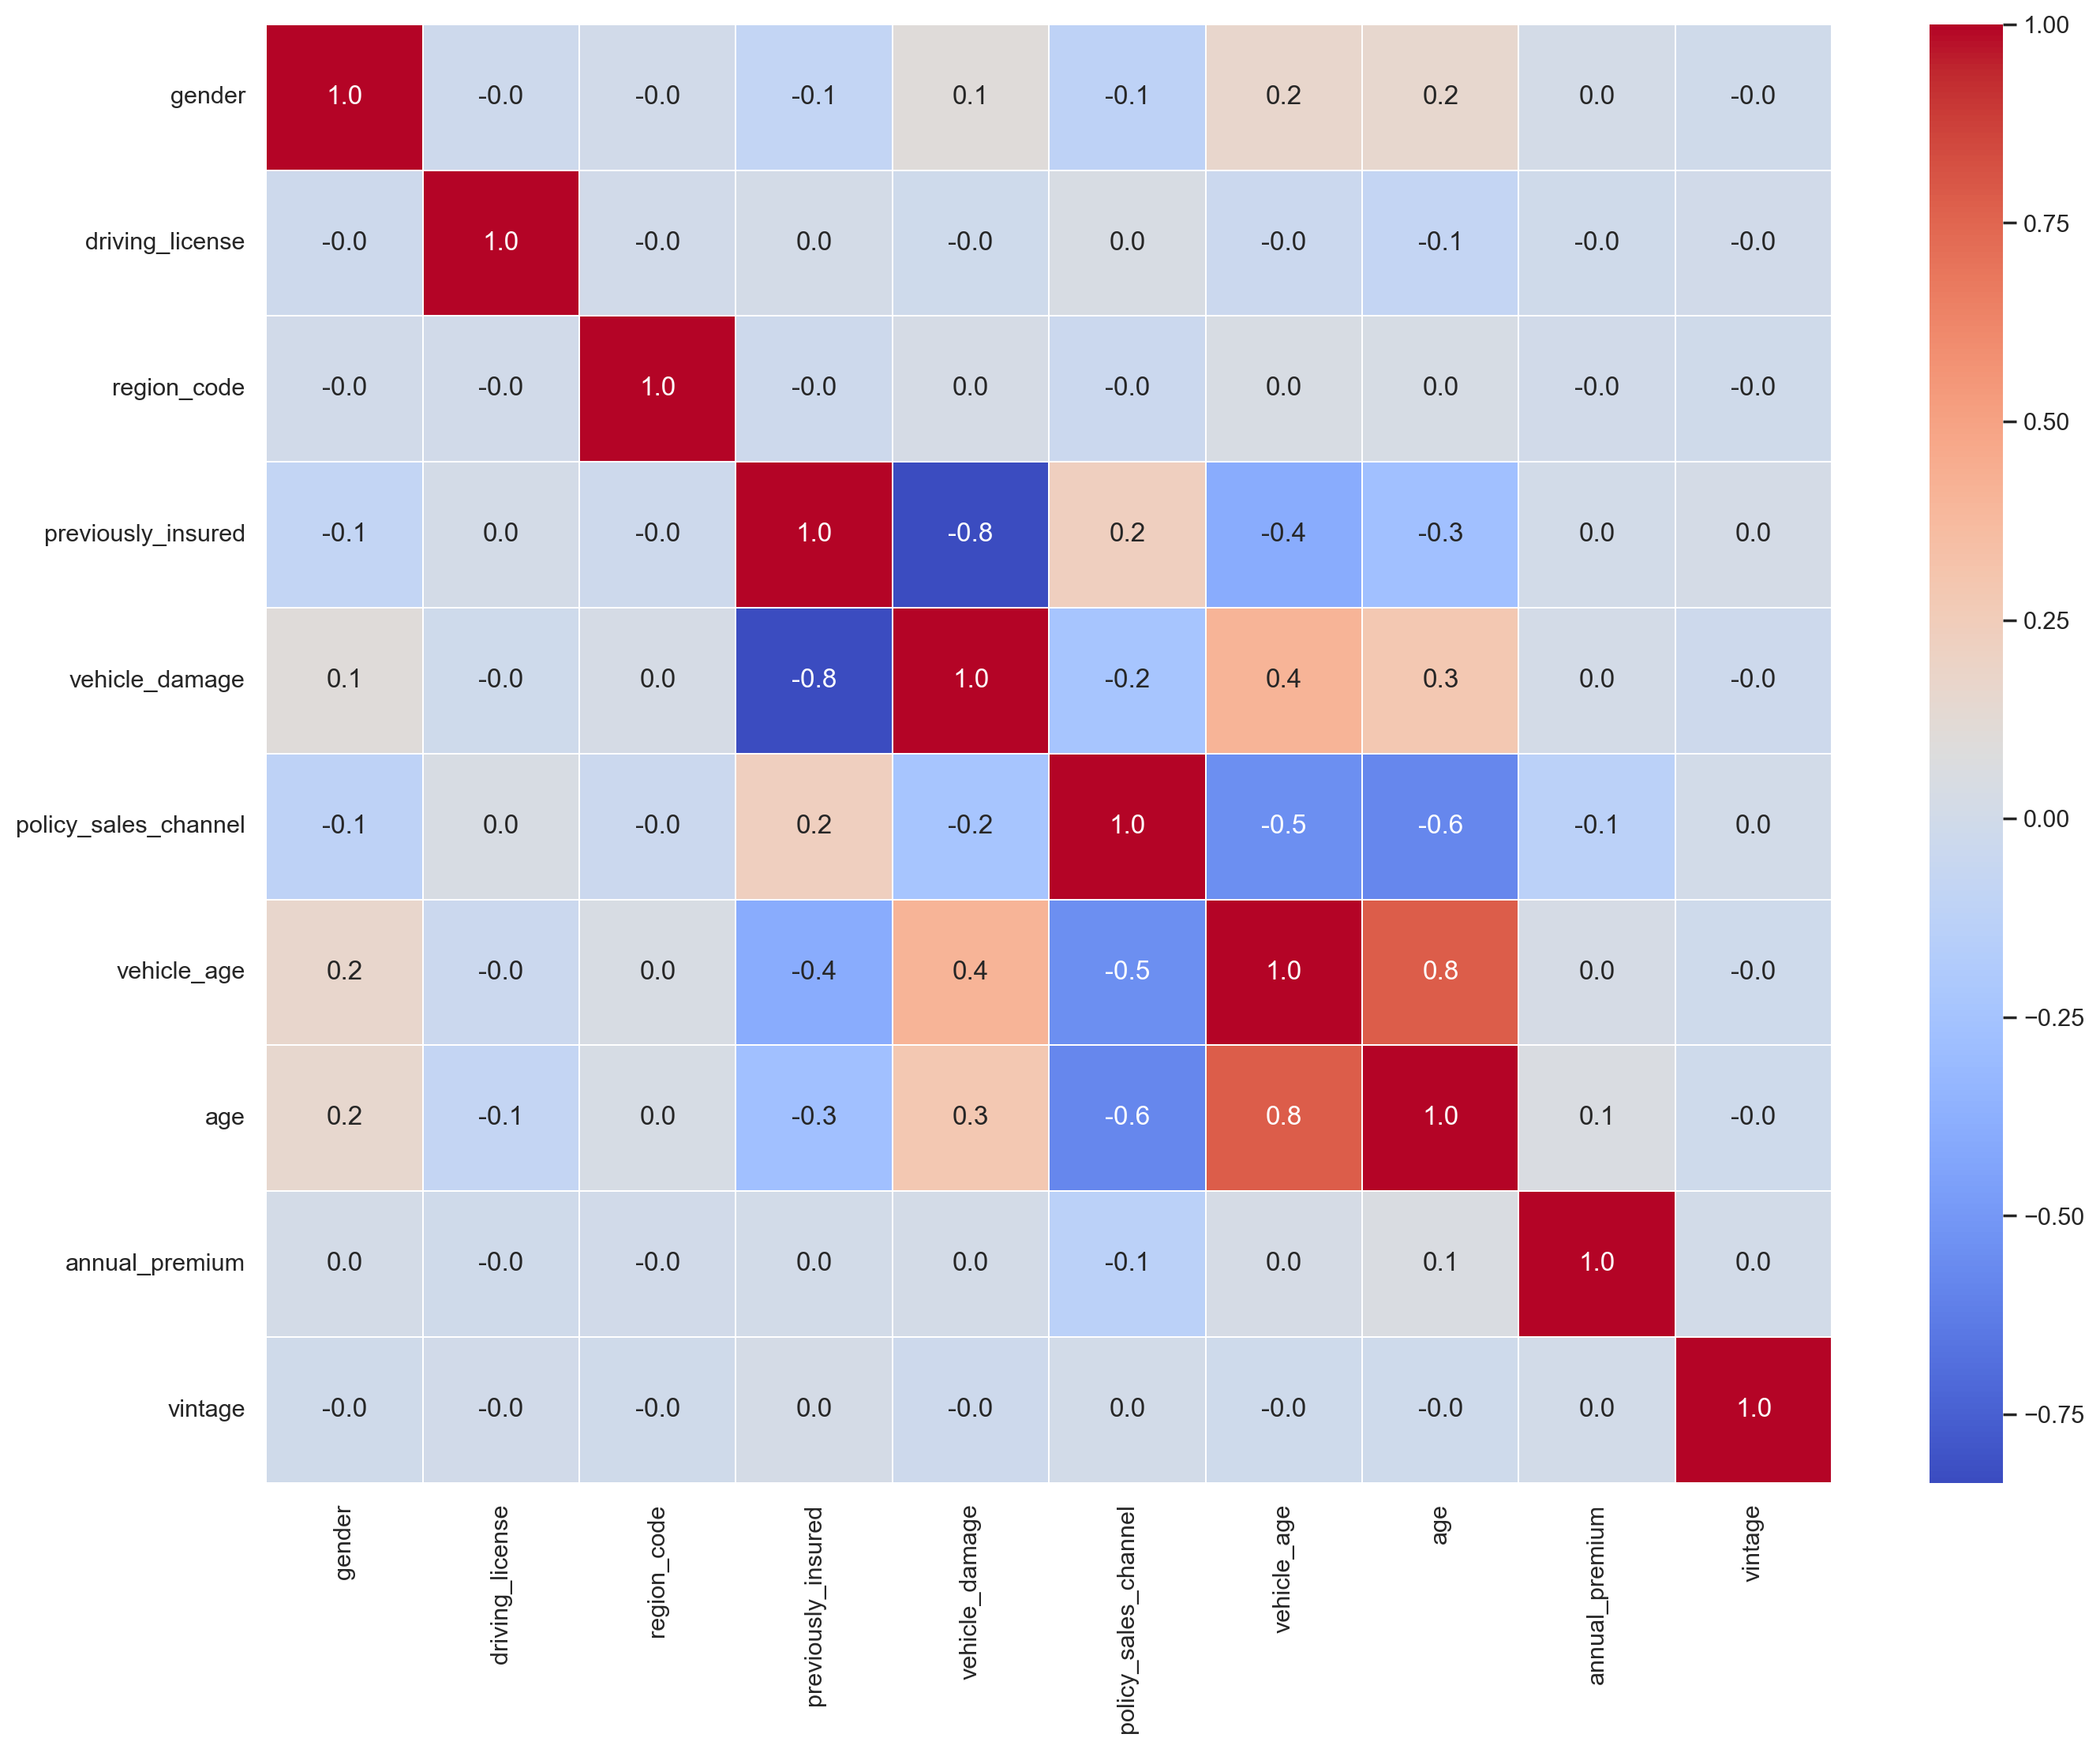

In [19]:
###### correlation matrix #######

# NOTE: Pearson correlation isn't very meaningful for categorical features
    # correlation for numerical features

corr_matrix = X_train.corr()

plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".1f", 
            cmap="coolwarm", 
            linewidths=0.1
           )

plt.show()

- a number of initial observations
    - previous record of vehicle damage shows strong negative correlation to having existing insurance
    - customer age and vehicle age are strongly correlated
    - moderate correlation between customer age and damage, as well as vehicle age and damage
        - this could be indication that older drivers tend to have more accidents, or simply that most older drivers have had their vehicles for longer, and thus naturally have been involved in more accidents over that longer time

In [27]:
###### mutual information #######

discrete_mask = np.arange(X_train.shape[1]-3)
    # this is just index values of all but the last 3 columns (because the last 3 are continuous features)
mi_scores = mutual_info_classif(X_train, y_train, discrete_features=discrete_mask)

mi = pd.Series(mi_scores)
mi.index = X_train.columns
mi = pd.DataFrame(mi.sort_values(ascending=False), columns = ["Mutual Information"])
mi.style.background_gradient("cool")

,Mutual Information
age,0.085734
vehicle_damage,0.082021
previously_insured,0.081773
annual_premium,0.079762
policy_sales_channel,0.042062
vehicle_age,0.028602
vintage,0.020474
region_code,0.011145
gender,0.001540
driving_license,0.000052


- all features have very low MI, which suggests some feature engineering may be needed

## Trials for various models

In [15]:
# dicts to store OOF predicted probabilities for each model, and fold accuracy scores for each model
model_oof_proba_dict = {}
model_fold_scores = {}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=15)

# define function with which to perform cross-validation for a given model
    # 5-fold cross-validation in which we consider OOF metrics at each fold, as well as overall AUC score    
def cross_validate_model(model, X, y, name):
    
    oof_proba = np.zeros(shape=(X.shape[0], 2)) # for each datapoint in X, save the predicted probability for both classes
    oof_acc = []
    for i, (train_idx, val_idx) in enumerate(kf.split(X,y)):
        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_train = y[train_idx]
        y_val = y[val_idx]
        
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_val)
        acc = accuracy_score(y_val, np.argmax(y_pred_proba, axis=1))
        print("fold {} accuracy: {:.4f}".format(i, acc))
        oof_acc.append(acc)
        oof_proba[val_idx] = y_pred_proba

    overall_acc = accuracy_score(y, np.argmax(oof_proba, axis=1))
    print("overall accuracy: {:.4f}".format(overall_acc))
    auc_score = roc_auc_score(y, oof_proba[:, 1])
    print("overall ROC AUC: {:.4f}".format(auc_score))
    
    model_oof_proba_dict[name] = oof_proba
    model_fold_scores[name] = oof_acc

In [29]:
X_preprocessed = X_train.copy()
y_preprocessed = y_train.copy()

### LightGBM (default)

In [33]:
model_lgbm = LGBMClassifier(verbose=-1)
cross_validate_model(model_lgbm, X_preprocessed, y_preprocessed, name="lgbm_untuned")

fold 0 accuracy: 0.8798
fold 1 accuracy: 0.8800
fold 2 accuracy: 0.8798
fold 3 accuracy: 0.8800
fold 4 accuracy: 0.8797
overall accuracy: 0.8799
overall ROC AUC: 0.8769


### Logistic regression (default)

In [44]:
model_LR_untuned = LogisticRegression()
cross_validate_model(model_LR_untuned, X_preprocessed, y_preprocessed, name="LR_untuned")

fold 0 accuracy: 0.8760
fold 1 accuracy: 0.8757
fold 2 accuracy: 0.8758
fold 3 accuracy: 0.8759
fold 4 accuracy: 0.8759
overall accuracy: 0.8759
overall ROC AUC: 0.8353


### Logistic Regression (w/ preprocessing, feature engineering)

In [57]:
# for logistic regression to be successful we should perform different preprocessing on the dataset
    # for numerical features, we will scale them and then produce new polynomial features based on those numerical features
    # for categorical features, we will use target encoding to transform them into numerical-style features

def dtype_converter(df, is_train=False):
    # this function will make the following simple changes to input dataframe:
        # convert float columns to int columns
        # convert int64 columns to int8 columns (reduce memory use)
        # convert object columns to int columns (effectively perform ordinal encoding)
    df = df.copy()

    df['age'] = df['age'].astype('int8')
    df['driving_license'] = df['driving_license'].astype('int8')
    df['region_code'] = df['region_code'].astype('int8')
    df['previously_insured'] = df['previously_insured'].astype('int8')
    df['annual_premium'] = df['annual_premium'].astype('int32')
    df['policy_sales_channel'] = df['policy_sales_channel'].astype('int16')
    df['vintage'] = df['vintage'].astype('int16')
    df['gender'] = df['gender'].map({'Female': 0, 'Male': 1}).astype('int8')
    df['vehicle_age'] = df['vehicle_age'].map({'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 3}).astype('int8')
    df['vehicle_damage'] = df['vehicle_damage'].map({'No': 0, 'Yes': 1}).astype('int8')

    if is_train==True:

        df['response'] = df['response'].astype('int8')

    return df

train_logistic = dtype_converter(df_train, is_train=True)
X_logistic = train_logistic.drop(columns=['response'], axis=1)
y_logistic = train_logistic['response']

num_cols = ['age', 'annual_premium', 'vintage']
cat_cols = ['gender', 'vehicle_age', 'vehicle_damage', 'region_code', 'policy_sales_channel']
    # note: binary features will not be encoded or scaled in any way 

step_1 = ColumnTransformer([('scaler', StandardScaler(), num_cols),
                            ('target_encoder', TargetEncoder(), cat_cols)],
                            remainder='passthrough').set_output(transform='pandas')

step_2 = ColumnTransformer([('poly', PolynomialFeatures(include_bias=False),
                            ['scaler__age', 'scaler__annual_premium', 'scaler__vintage'])],
                            remainder='passthrough').set_output(transform='pandas')

feature_transforms = Pipeline([('scaling_encoding', step_1),
                               ('poly_features', step_2)])

model_LR_2 = Pipeline([('transformations', feature_transforms),
                       ('logistic_regression', LogisticRegression(C=0.1, solver='newton-cholesky'))])

cross_validate_model(model_LR_2, X_logistic, y_logistic, name="LR_2")

fold 0 accuracy: 0.8769
fold 1 accuracy: 0.8769
fold 2 accuracy: 0.8769
fold 3 accuracy: 0.8769
fold 4 accuracy: 0.8769
overall accuracy: 0.8769
overall ROC AUC: 0.8528


### Neural Network (simple architecture)

In [9]:
# first, we define 2 functions
    # first function changes columns' dtypes to reduce their sizes
    # second function builds a keras Sequential model with simple architecture (series of dense layers with fewer units)

def size_reduction(df, is_train=False):
    df = df.copy()

    df['age'] = df['age'].astype('int8')
    df['driving_license'] = df['driving_license'].astype('int8')
    df['region_code'] = df['region_code'].astype('int8')
    df['previously_insured'] = df['previously_insured'].astype('int8')
    df['annual_premium'] = df['annual_premium'].astype('int32')
    df['policy_sales_channel'] = df['policy_sales_channel'].astype('int16')
    df['vintage'] = df['vintage'].astype('int16')
    df['gender'] = df['gender'].map({'Female': 0, 'Male': 1}).astype('int8')
    df['vehicle_age'] = df['vehicle_age'].map({'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 3}).astype('int8')
    df['vehicle_damage'] = df['vehicle_damage'].map({'No': 0, 'Yes': 1}).astype('int8')

    if is_train==True:
        df['response'] = df['response'].astype('int8')

    return df

# given our very large dataset, train-test-split (as opposed to cross-validation) should suffice
train_reduced = size_reduction(df_train, True)
X_train_nn, X_val_nn = train_test_split(train_reduced, test_size=0.2, stratify=train_reduced.response, random_state=1)
y_train_nn = X_train_nn.pop('response')
y_val_nn = X_val_nn.pop('response')

def get_model(meta):
    model = keras.Sequential()
    model.add(keras.Input(meta["X_shape_"][1:]))
    model.add(keras.layers.Dense(128, kernel_initializer="lecun_normal", activation="selu"))
    model.add(keras.layers.Dense(64, kernel_initializer="lecun_normal", activation="selu"))
    model.add(keras.layers.Dense(1, kernel_initializer="lecun_normal", activation="sigmoid"))
    return model

In [10]:
X_train_nn.head()

,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage
1385829,1,28,1,30,1,0,0,27499,152,246
5362197,0,41,1,28,0,1,1,28298,26,212
2246796,0,33,1,3,1,0,0,27193,152,248
5924265,1,29,1,36,1,0,0,55924,152,282
11131290,0,42,1,50,1,1,0,38322,26,253


- our preprocessing strategy for NN model is as follows 
    - one-hot encode most categorical features
        - if we used other encoding (e.g. ordinal encoding), the model might learn patterns in the arbitrary encoding values
    - 'annual_premium' and 'vintage' will be treated like categorical features (even though they are meant to be continuous)
        - we find their partial dependence diagrams to appear erratic
        - partial dependence diagrams of ordinal or continous variables shouldn't have many local maxima and minima
        - 'annual_premium' has too many unique vals, so we will target encode it (not OHE)
        - 'vintage' will be one-hot encoded
    - 'age' is the only feature that is treated like a continuous variable - it will be scaled(standardized)
    - finally, the binary features 'driving_license' and 'previously_insured' do not require preprocessing  

In [12]:
ohe_columns = ['gender', 'region_code', 'vehicle_age', 'vehicle_damage', 'policy_sales_channel', 'vintage']

# make a Pipeline object that contains (A) columntransformer to deal with encoding and scaling, and (B) the model itself
# we use KerasClassifier to facilitate using sklearn and Keras together
# NOTE: due to memory limitations, we will not make use of callbacks based on validation

nn_model = make_pipeline(
    ColumnTransformer(
        [('one-hot-encode', OneHotEncoder(drop='first', dtype=np.int16, max_categories=200), ohe_columns),
        ('target-encode', make_pipeline(TargetEncoder(), FunctionTransformer(lambda x: x.astype(np.float32)), StandardScaler(copy=False)), ['annual_premium']),
        ('scale', StandardScaler(copy=False), ['age'])],
        remainder='passthrough',
        #sparse_threshold=0,
        #n_jobs=-1
    ),
    
    KerasClassifier(
        get_model,
        loss="binary_crossentropy",
        optimizer=keras.optimizers.Adam(learning_rate=0.003),
        #validation_split=0.05,
        batch_size=1024,
        #validation_batch_size=65536,
        epochs=20,
        #callbacks=[keras.callbacks.ReduceLROnPlateau(patience=3),
        #           keras.callbacks.EarlyStopping(patience=5)]
    )
)

nn_model.fit(X_train_nn, y_train_nn)
y_pred_proba = nn_model.predict_proba(X_val_nn)
print(f"# AUC: {roc_auc_score(y_val_nn, y_pred_proba[:, 1]):.5f}")

Epoch 1/20
8989/8989 [==============================] - 244s 21ms/step - loss: 0.2488
Epoch 2/20
8989/8989 [==============================] - 200s 21ms/step - loss: 0.2471
Epoch 3/20
8989/8989 [==============================] - 234s 25ms/step - loss: 0.2468
Epoch 4/20
8989/8989 [==============================] - 273s 29ms/step - loss: 0.2466
Epoch 5/20
8989/8989 [==============================] - 315s 34ms/step - loss: 0.2465
Epoch 6/20
8989/8989 [==============================] - 325s 34ms/step - loss: 0.2464
Epoch 7/20
8989/8989 [==============================] - 349s 37ms/step - loss: 0.2463
Epoch 8/20
8989/8989 [==============================] - 388s 42ms/step - loss: 0.2462
Epoch 9/20
8989/8989 [==============================] - 396s 43ms/step - loss: 0.2462
Epoch 10/20
8989/8989 [==============================] - 407s 44ms/step - loss: 0.2462
Epoch 11/20
8989/8989 [==============================] - 405s 44ms/step - loss: 0.2461
Epoch 12/20
8989/8989 [=============================

**NOTE** : I don't know how to save a Pipeline object containing transformer and KerasClassifier components (standard .save() method in Keras does not work)

the methods that I tried:

- METHOD 1
- nn_model.save("nn_1.keras")
- nn_model.pred

- METHOD 2
- nn_model_json = nn_model.to_json()
- with open("nn_model.json", "w") as json_file:
-     json_file.write(nn_model_json) 
- nn_model.save_weights("nn_model_weights.h5")

- METHOD 3
- import pickle
- pkl_file_name = "nn_1.pkl"
- with open(pkl_file_name, "wb") as f:
-     pickle.dump(nn_model, f)

In [14]:
# different run: same model fitted for 5 epochs only
y_pred_proba = pipeline.predict_proba(X_val_nn)
print(f"# AUC: {roc_auc_score(y_val_nn, y_pred_proba[:, 1]):.5f}")

2248/2248 [==============================] - 59s 26ms/step
# AUC: 0.88748


- we see that after 5~6 epochs of training, our NN model performance does not improve significantly
    - after  5 epochs: AUC=0.88748
    - after 20 epochs: AUC=0.88799
    
- even if we take into account stochastic nature of fitting process (meaning that no 2 runs are identical) the lack of improvement after 4x epochs suggests this model has reached its limitations

In [52]:
ohe_columns = ['gender', 'region_code', 'vehicle_age', 'vehicle_damage', 'policy_sales_channel', 'vintage']

nn_model_brief = make_pipeline(
    ColumnTransformer(
        [('one-hot-encode', OneHotEncoder(drop='first', dtype=np.int16, max_categories=200, handle_unknown='ignore'), ohe_columns),
        ('target-encode', make_pipeline(TargetEncoder(), FunctionTransformer(lambda x: x.astype(np.float32)), StandardScaler(copy=False)), ['annual_premium']),
        ('scale', StandardScaler(copy=False), ['age'])],
        remainder='passthrough',
        #sparse_threshold=0,
        #n_jobs=-1
    ),
    
    KerasClassifier(
        get_model,
        loss="binary_crossentropy",
        optimizer=keras.optimizers.Adam(learning_rate=0.003),
        #validation_split=0.05,
        batch_size=1024,
        #validation_batch_size=65536,
        epochs=5,
        #callbacks=[keras.callbacks.ReduceLROnPlateau(patience=3),
        #           keras.callbacks.EarlyStopping(patience=5)]
    )
)

#with parallel_backend(backend="loky", mmap_mode="r+"):
nn_model_brief.fit(X_train_nn, y_train_nn)
y_pred_proba = nn_model_brief.predict_proba(X_val_nn)
print(f"# AUC: {roc_auc_score(y_val_nn, y_pred_proba[:, 1]):.5f}")

Epoch 1/5
8989/8989 [==============================] - 708s 76ms/step - loss: 0.2488
Epoch 2/5
8989/8989 [==============================] - 809s 88ms/step - loss: 0.2471
Epoch 3/5
8989/8989 [==============================] - 827s 90ms/step - loss: 0.2468
Epoch 4/5
8989/8989 [==============================] - 915s 100ms/step - loss: 0.2466
Epoch 5/5
2248/2248 [==============================] - 43s 19ms/step
# AUC: 0.88744


In [54]:
test_redc = size_reduction(df_test)

y_pred_proba = nn_model_brief.predict_proba(test_redc)

y_pred = y_pred_proba[:, 1]

submission_series = pd.Series(data=y_pred, index=test_redc.index, name="Response")

filename = 'submission_nn_brief.csv'
submission_series.to_csv(filename)

7491/7491 [==============================] - 246s 33ms/step


## initial simple LGBM model result submission

In [183]:
model_lgbm.fit(X_preprocessed, y_preprocessed)
simple_pred_probas = model_lgbm.predict_proba(X_test)

In [191]:
pred_vals = simple_pred_probas[:, 1]
submission_series = pd.Series(data=pred_vals, index=X_test.index, name="Response")
submission_series

id
11504798    0.011855
11504799    0.430730
11504800    0.246982
11504801    0.000196
11504802    0.041009
              ...   
19174659    0.199559
19174660    0.000202
19174661    0.000720
19174662    0.539334
19174663    0.000200
Name: Response, Length: 7669866, dtype: float64

In [192]:
filename = 'submission_lgbm_simple.csv'
submission_series.to_csv(filename)

## Hyperparameter tuning

In [39]:
# use Optuna to optimize hyperparams

def objective(trial, X=X_preprocessed, y=y_preprocessed):
    cv = StratifiedKFold(n_splits=5, shuffle=True)
    params = {
        "objective": "binary",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "num_leaves": trial.suggest_int('num_leaves', 2, 500),
        "learning_rate": trial.suggest_float('learning_rate',0.01, 0.3),
        "n_estimators": trial.suggest_int('n_estimators', 100, 1000),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),     
        }
    callback = lgb.early_stopping(stopping_rounds=50, verbose=False)
    oof_roc_scores = []
    
    # since our dataset is large, we will use a train-test split rather than cross-validation
    # but we will instead give generous early-stopping threshold

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=7)     
    model = LGBMClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)],  eval_metric="auc", callbacks=[callback])

    y_pred_proba = model.predict_proba(X_val)
    roc_score = roc_auc_score(y_val, y_pred_proba[:, 1])
    
    return roc_score
    
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

[I 2024-07-15 17:39:03,159] A new study created in memory with name: no-name-4e333cfa-b663-4ba0-b134-cd88feb04e56
[I 2024-07-15 17:40:52,878] Trial 0 finished with value: 0.8803606010090029 and parameters: {'num_leaves': 94, 'learning_rate': 0.23400840156762884, 'n_estimators': 888, 'reg_alpha': 2.8569501457395163, 'reg_lambda': 1.8294539030626268e-08}. Best is trial 0 with value: 0.8803606010090029.
[I 2024-07-15 17:42:14,598] Trial 1 finished with value: 0.8803731254165887 and parameters: {'num_leaves': 301, 'learning_rate': 0.13290501609267522, 'n_estimators': 155, 'reg_alpha': 0.0008063668977193637, 'reg_lambda': 0.41741427858075464}. Best is trial 1 with value: 0.8803731254165887.
[I 2024-07-15 17:42:59,787] Trial 2 finished with value: 0.8794629069954656 and parameters: {'num_leaves': 381, 'learning_rate': 0.2283255719278241, 'n_estimators': 763, 'reg_alpha': 1.0825683447916587e-07, 'reg_lambda': 0.0002072577363222393}. Best is trial 1 with value: 0.8803731254165887.
[I 2024-07-1

KeyboardInterrupt: 

In [40]:
study.best_params

{'num_leaves': 120,
 'learning_rate': 0.10518065521913668,
 'n_estimators': 695,
 'reg_alpha': 0.00012071073325579139,
 'reg_lambda': 5.266882338359835}

In [41]:
tuned_params = {
    'num_leaves': 120,
    'learning_rate': 0.10518065521913668,
    'n_estimators': 695,
    'reg_alpha': 0.00012071073325579139,
    'reg_lambda': 5.266882338359835
    }

lgbm1 = LGBMClassifier(**tuned_params)
cross_validate_model(lgbm1, X_preprocessed, y_preprocessed, name="lgbm_1")

[LightGBM] [Info] Number of positive: 1132047, number of negative: 8071790
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.126052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 748
[LightGBM] [Info] Number of data points in the train set: 9203837, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.122997 -> initscore=-1.964348
[LightGBM] [Info] Start training from score -1.964348
fold 0 accuracy: 0.8811
[LightGBM] [Info] Number of positive: 1132047, number of negative: 8071790
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.127346 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 750
[LightGBM] [Info] Number of data points in the train set: 9203837, number of us

In [42]:
lgbm1.fit(X_preprocessed, y_preprocessed)

y_pred_prob = lgbm1.predict_proba(X_test)
pred_vals = y_pred_prob[:, 1]

submission_series = pd.Series(data=pred_vals, index=X_test.index, name="Response")

filename = 'submission_lgbm_1.csv'
submission_series.to_csv(filename)

[LightGBM] [Info] Number of positive: 1415059, number of negative: 10089738
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.098593 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 740
[LightGBM] [Info] Number of data points in the train set: 11504797, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.122997 -> initscore=-1.964348
[LightGBM] [Info] Start training from score -1.964348


# Try out better models

## Neural network model with better structure

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Sequential

In [25]:
RANDOM_STATE = 2112
np.random.seed(RANDOM_STATE)

In [13]:
TARGET = 'response'

# we will encode every feature like a categorical (even if they may not actually be categorical)
cont_features = []    
cat_features = ['gender', 'driving_license', 'previously_insured', 'vehicle_age', 'vehicle_damage', 
                'policy_sales_channel', 'region_code', 'age', 'vintage', 'annual_premium']

all_data = pd.concat([df_train, df_test])

# apply ordinal encoding to all features (this excludes target variable) and make their values 'int' type
# NOTE: we run fit_transform() on combined training and test dataset 
    # this means the ordinal encoder encounters and encodes all unique values in every feature of both train and test sets
    # if we fit only on train, then transform() on test could result in error
ord_enc = OrdinalEncoder()
all_data[cat_features] = ord_enc.fit_transform(all_data.filter(cat_features)).astype('int')

# keep track of cardinality (i.e. number of unique vals) for each feature
feature_cardinality = {}
for feature in cat_features:
    feature_cardinality[feature] = all_data[feature].max() + 1

# now that we're done with encoding, we want to treat the binary features like continuous variables
# while all other features will be sent as input to an embedding layer
cont_features = ['gender', 'driving_license', 'previously_insured', 'vehicle_damage']
cat_features = ['vehicle_age', 'policy_sales_channel', 'region_code', 'age', 'vintage', 'annual_premium']

# separate rows back into train and test sets - base this on whether each row has a value or a null for the 'response' column
train_data = all_data.query(f"not {TARGET}.isna()")
test_data  = all_data.query(f"{TARGET}.isna()").drop(columns=[TARGET])

features = cont_features + cat_features

# tidy up
all_data = None
import gc
gc.collect()

20

In [14]:
train_data.filter(features).describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
gender,11504797.0,0.541351,0.498287,0.0,0.0,1.0,1.0,1.0
driving_license,11504797.0,0.998022,0.044431,0.0,1.0,1.0,1.0,1.0
previously_insured,11504797.0,0.462997,0.498629,0.0,0.0,0.0,1.0,1.0
vehicle_damage,11504797.0,0.502680,0.499993,0.0,0.0,1.0,1.0,1.0
vehicle_age,11504797.0,0.521530,0.576739,0.0,0.0,0.0,1.0,2.0
policy_sales_channel,11504797.0,106.972225,51.161584,0.0,28.0,143.0,144.0,153.0
region_code,11504797.0,26.418689,12.991590,0.0,15.0,28.0,35.0,52.0
age,11504797.0,18.383565,14.993458,0.0,4.0,16.0,29.0,65.0
vintage,11504797.0,153.897752,79.979530,0.0,89.0,156.0,222.0,289.0
annual_premium,11504797.0,16250.794763,11626.913583,0.0,8675.0,15221.0,22848.0,53957.0


In [19]:
# we will define a custom "mish" function (Self Regularized Non-Monotonic Activation Function)
    # https://github.com/digantamisra98/Mish
    # https://www.kaggle.com/code/imokuri/mish-activation-function

from tensorflow.keras.layers import Activation
from tensorflow.keras.utils import get_custom_objects

class Mish(Activation):
    '''
    Mish Activation Function.
    .. math::
        mish(x) = x * tanh(softplus(x)) = x * tanh(ln(1 + e^{x}))
    Shape:
        - Input: Arbitrary. Use the keyword argument `input_shape`
        (tuple of integers, does not include the samples axis)
        when using this layer as the first layer in a model.
        - Output: Same shape as the input.
    Examples:
        >>> X = Activation('Mish', name="conv1_act")(X_input)
    '''

    def __init__(self, activation, **kwargs):
        super(Mish, self).__init__(activation, **kwargs)
        self.__name__ = 'Mish'


def mish(inputs):
    return inputs * tf.math.tanh(tf.math.softplus(inputs))

get_custom_objects().update({'Mish': Mish(mish)})

In [20]:
# now we will build up the model architecture

def build_model(cat_features, cont_features):
    # each feature in cat_features has separate input layer (all put into a list)
    # all features in cont_features are bundled into a single layer
    cat_inputs = [layers.Input(shape=(1,), name=f'cat{i}') for i in range(len(cat_features))]
    cont_inputs = layers.Input(shape=(len(cont_features),))
                                
    # make embedding layer, dropout layer, and flatten layer for each of the cat_feature input layers
    flat_embeddings = []
    for i, f in enumerate(cat_features):
        input_dim = int(feature_cardinality[f])
        output_dim = int(min(64, round(1.6 * input_dim ** .56))) # based on the fastai library
        embedding = layers.Embedding(input_dim=input_dim, output_dim=output_dim)(cat_inputs[i])
            # input_dim denotes vocab size (i.e. number of all possible discrete values) which we can get via cardinality
            # output_dim denotes the number of elements we want in our embedded vector (capped to 64)
        embedding = layers.SpatialDropout1D(.3)(embedding)
        flat_embeddings.append(layers.Flatten()(embedding))
            # so for each layer in cat_inputs, we have its output after it is run thru embedding, dropout, and flatten
                                
    # concat all flat_embedding layers and the cont_input layer, and then normalize them
    concatenated_inputs = layers.Concatenate()(flat_embeddings + [cont_inputs, ])
    concatenated_inputs_bn = layers.BatchNormalization()(concatenated_inputs)

    # run thru dense and normalization layers -> this output is concatenated with a skip connection to concatenated_inputs_bn
    # after that, another sequence of dense, dropout, normalization
    x = layers.Dense(256, activation='Mish')(concatenated_inputs_bn)
    x = layers.BatchNormalization()(x)
    for units in (128,):
        inp = layers.Concatenate()([x, concatenated_inputs_bn])
        x = layers.Dense(units=units, activation='Mish')(inp)
        x = layers.Dropout(.3)(x)
        x = layers.BatchNormalization()(x)

    # output layer -> 1 unit and sigmoid means we get predicted P(y=1) as model output
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(cat_inputs + [cont_inputs], outputs)

epochs = 4
callbacks = []

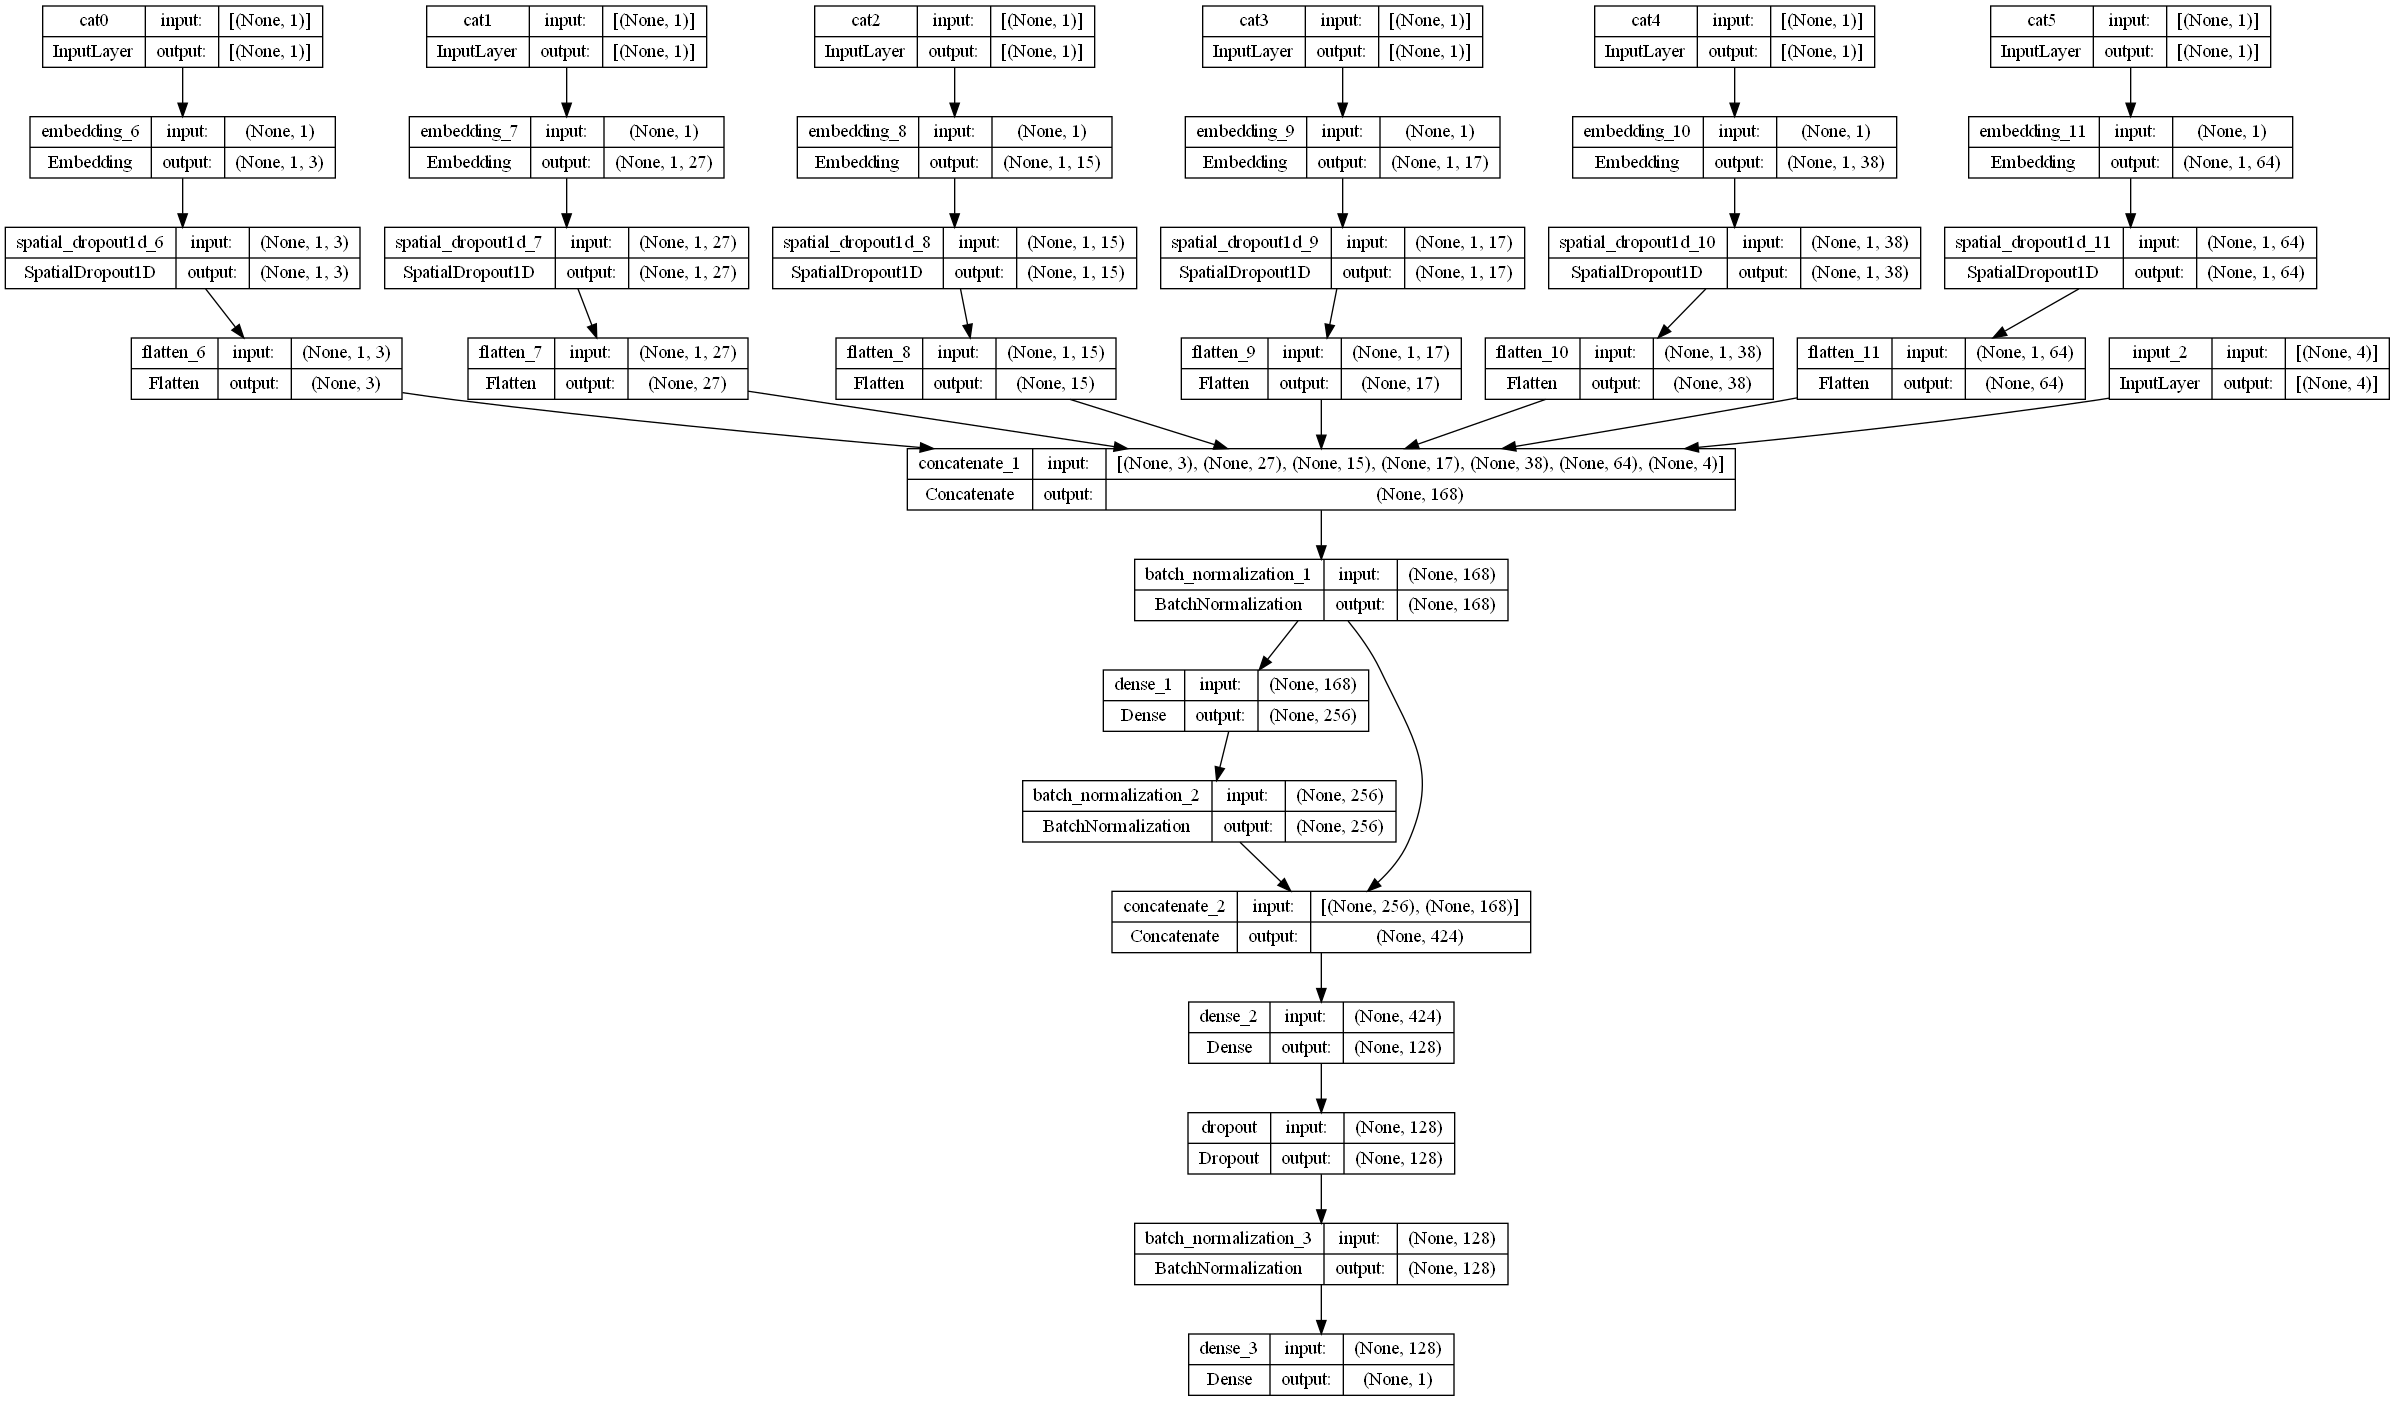

In [21]:
# visualize model architecture
tf.keras.utils.plot_model(
    model=build_model(cat_features, cont_features), 
    show_shapes=True, 
    rankdir='TB')

In [30]:
# when feeding the data to our NN, we feed the categorical features column-by-column
# while the continuous features are fed as one lump
cat_idxs= []
cont_idxs = []
for f in cat_features:
    cat_idxs.append([features.index(f)])
for f in cont_features:
    cont_idxs.append(features.index(f))
    
feature_idxs = cat_idxs + [cont_idxs]
    # we get list of lists: [[4], [5], [6], [7], [8], [9], [0, 1, 2, 3]]
    # indices of each cat feature is separate list, while cont features are grouped together

def prep_to_feed(df):
    X = df[features].values
    prepped = []
    for i in feature_idxs:
        prepped.append(X[:, i])
    return prepped

# fit_fold() will fit the model to the train set, and then predict for val and test sets
# it also calculates the val AUC score, and finally returns all 3 things
def fit_fold(train, val, test):

    model = build_model(cat_features, cont_features)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1E-4),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC()])

    history = model.fit(
          prep_to_feed(train), train[TARGET],
          validation_data=(prep_to_feed(val), val[TARGET]),
          batch_size=BS,
          epochs=epochs,
          callbacks=callbacks,
          verbose=0
    )

    val_pred = model.predict(prep_to_feed(val), verbose=0, batch_size=BS).flatten()
    test_pred = model.predict(prep_to_feed(test), verbose=0, batch_size=BS).flatten()
    
    val_metric = roc_auc_score(val[TARGET], val_pred)
    return val_pred, test_pred, val_metric

In [31]:
N_FOLDS = 5
BS = 1024

val_preds = np.zeros(len(train_data))
test_preds = np.zeros(len(test_data))
val_metrics = []

keras.utils.set_random_seed(RANDOM_STATE)
k_fold = StratifiedKFold(n_splits=N_FOLDS, random_state=RANDOM_STATE, shuffle=True)
for i, (train_idx, val_idx) in enumerate(k_fold.split(train_data, train_data[TARGET])):
    fold_train = train_data.loc[train_idx]
    fold_val = train_data.loc[val_idx]

    val_pred, test_pred, val_metric = fit_fold(fold_train, fold_val, test_data)
    
    print(f'  -- fold {i} auc: {val_metric:2.4f}')
    val_metrics.append(val_metric)
    val_preds[val_idx] += val_pred
        # with each fold we will get predictions for 1/5 of the training data
    test_preds += test_pred / N_FOLDS
        # each fold predicts for full test set
        # to get average prediction over all 5 folds, divide the fold predictions by 5 so that each fold essentially has 0.2 weight coef

overall_val_metric = roc_auc_score(train_data[TARGET], val_preds)
print(f'  ----------- {overall_val_metric:2.4f}')

  -- fold 0 auc: 0.8918


KeyboardInterrupt: 